# Length of Stay - Multi-Model Comparison (with added data)


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modern gradient-boosting libraries (added on top of the starter's models).
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

# Data Processing

### Loading the data

In [2]:

train_df = pd.read_csv("../data/VFL_2026_TRAIN_SET.csv")
test_df  = pd.read_csv("../data/VFL_2026_TEST_SET.csv")

# for _df in (train_df, test_df):
#     _df["ENCOUNTER_KEY"] = _df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True)
print("train:", train_df.shape, "| test:", test_df.shape)

train: (100000, 46) | test: (15000, 45)


### Exploring data

Target in train only: {'ADMIT_LOS'}

Missing values (train):
PROCEDURE_SUBCAT_DESC    32.07
PROCEDURE_LONG_DESC      32.07
dtype: float64


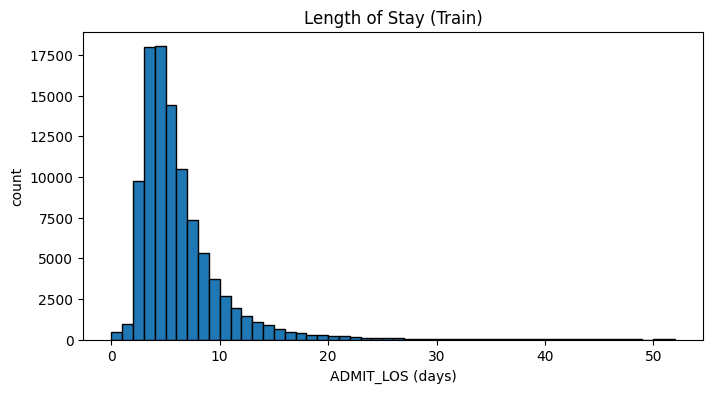

In [3]:
print("Target in train only:", set(train_df.columns) - set(test_df.columns))
print("\nMissing values (train):")
m = train_df.isna().mean()
print((m[m > 0] * 100).round(2))
plt.figure(figsize=(8,4))
plt.hist(train_df["ADMIT_LOS"], bins=range(0, int(train_df["ADMIT_LOS"].max())+2), edgecolor="black")
plt.title("Length of Stay (Train)"); plt.xlabel("ADMIT_LOS (days)"); plt.ylabel("count"); plt.show()

## Clean & build features (with the added data)


In [4]:
def strip_num(x): return pd.to_numeric(x.astype(str).str.strip(), errors="coerce")

target  = "ADMIT_LOS"
numeric = ["ICU_DAYS","ORDER_TOTAL_CHARGES","PATIENT_AGE","OPERATION_COUNT","NUM_VISITS","ADMIT_MTH",
           "MS_DRG_CODE","ZIP","X","Y","DX_CODE","ICD9_TARGET","ORDER_SET_USED","DIAGNOSIS_ICD_CODE"]
numeric_text = ["NUM_CHRONIC_COND","DRG_APR_SEVERITY","PROCEDURE_SUBCAT_CODE"]
extra   = ["MONITORING_HOURS","COMORBIDITY_INDEX","CARE_TEAM_SIZE"]            # the added columns
categorical = ["DOCTOR","DEPARTMENT","DISCHARGED_TO","STANDARD_ORDERS_USED","DISCH_NURSE_ID","GENDER",
               "STATECODE","REGION","RACE_CD","DIAGNOSIS_GROUP","DRG_APR_CODE","DIAGNOSIS_SUBCAT_CODE",
               "PROCEDURE_ICD_CODE","HOSPITAL"]

def build_features(df):
    X = pd.DataFrame(index=df.index)
    for c in numeric + numeric_text + extra:
        X[c] = pd.to_numeric(df[c], errors="coerce").fillna(-1)
    # engineered features (the "added data")
    icu = pd.to_numeric(df["ICU_DAYS"], errors="coerce")
    ch  = pd.to_numeric(df["ORDER_TOTAL_CHARGES"], errors="coerce")
    op  = pd.to_numeric(df["OPERATION_COUNT"], errors="coerce")
    mth = pd.to_numeric(df["ADMIT_MTH"], errors="coerce")
    X["charge_per_icu"] = (ch / icu.replace(0, np.nan)).fillna(0)
    X["charge_per_op"]  = (ch / op.replace(0, np.nan)).fillna(0)
    X["icu_x_sev"]      = icu * strip_num(df["DRG_APR_SEVERITY"])
    X["mon_per_icu"]    = (pd.to_numeric(df["MONITORING_HOURS"], errors="coerce") / icu.replace(0, np.nan)).fillna(0)
    X["mth_sin"]        = np.sin(2*np.pi*mth/12)
    X["mth_cos"]        = np.cos(2*np.pi*mth/12)
    for c in categorical:
        X[c] = df[c].astype(str).str.strip().fillna("NA")     # strings -> native categoricals
    return X

X_all = build_features(train_df)
X_sub = build_features(test_df)
y_all = train_df[target].astype(float)
cat_idx = [X_all.columns.get_loc(c) for c in categorical]
print(f"{X_all.shape[1]} features ({len(numeric)+len(numeric_text)+len(extra)} numeric+added, "
      f"{len(categorical)} categorical)")

# Ordinal-encoded copy for the scikit-learn models (they need numbers, not strings).
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_all_ord = X_all.copy(); X_sub_ord = X_sub.copy()
X_all_ord[categorical] = enc.fit_transform(X_all[categorical])
X_sub_ord[categorical] = enc.transform(X_sub[categorical])
X_all_ord = X_all_ord.astype(float); X_sub_ord = X_sub_ord.astype(float)

40 features (20 numeric+added, 14 categorical)


### Partition the data

In [5]:
idx = np.arange(len(X_all))
tr_i, tmp_i = train_test_split(idx, test_size=0.30, random_state=42)
val_i, hold_i = train_test_split(tmp_i, test_size=0.30, random_state=42)
y = y_all.values
print(f"train {len(tr_i):,} | val {len(val_i):,} | holdout {len(hold_i):,}")

train 70,000 | val 21,000 | holdout 9,000


# Model Building

## Testing different models


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

val_pred = {}


sk = {
    # "Linear":            LinearRegression(),
    # "Random Forest":     RandomForestRegressor(n_estimators=120, max_depth=20, n_jobs=-1, random_state=42),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
                             min_samples_leaf=40, l2_regularization=2.0, categorical_features=cat_idx,
                             early_stopping=True, validation_fraction=0.1, n_iter_no_change=40, random_state=7),
    "XGBoost":           xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=7, min_child_weight=5,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=7, verbosity=0),
    "LightGBM":          lgb.LGBMRegressor(n_estimators=1200, learning_rate=0.03, num_leaves=63, min_child_samples=40,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=2.0, random_state=7, verbose=-1),
}
for name, model in sk.items():
    model.fit(X_all_ord.iloc[tr_i], y[tr_i])
    val_pred[name] = np.clip(model.predict(X_all_ord.iloc[val_i]), 0, None)
    print(f"trained (scikit-learn): {name}")


cb = CatBoostRegressor(iterations=1500, learning_rate=0.03, depth=8, l2_leaf_reg=3.0, random_seed=7, verbose=0)
cb.fit(Pool(X_all.iloc[tr_i], y[tr_i], cat_features=cat_idx))
val_pred["CatBoost"] = np.clip(cb.predict(Pool(X_all.iloc[val_i], cat_features=cat_idx)), 0, None)
print("trained (CatBoost, native categoricals): CatBoost")

trained (scikit-learn): Gradient Boosting
trained (scikit-learn): XGBoost
trained (scikit-learn): LightGBM
trained (CatBoost, native categoricals): CatBoost


## Using SAS Viya

In [7]:
sas_val = {}

# from sasviya.ml.linear_model import LinearRegression as Linear
# from sasviya.ml.tree import ForestRegressor as Forest, GradientBoostingRegressor as GB
# sas_models = {
#     "Linear":            Linear(),
#     "Random Forest":     Forest(n_estimators=120, max_depth=20, random_state=42),
#     "Gradient Boosting": GB(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=7),
# }
# for name, model in sas_models.items():
#     model.fit(X_all_ord.iloc[tr_i], y[tr_i])
#     sas_val[f"{name} (SAS Viya)"] = np.clip(model.predict(X_all_ord.iloc[val_i]), 0, None)
#     print(f"trained (SAS Viya): {name}")


# Model Eval

In [8]:
rows = []
for name, p in {**{k:v for k,v in val_pred.items()}, **sas_val}.items():
    lbl = name if name.endswith(")") else f"{name} (scikit-learn)"
    rows.append({"Model": lbl,
                 "RMSE": round(mean_squared_error(y[val_i], p) ** 0.5, 4),
                 "MAE":  round(mean_absolute_error(y[val_i], p), 4),
                 "R2":   round(r2_score(y[val_i], p), 4)})
results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("Validation-set comparison (lower RMSE is better):")
print(results.to_string(index=False))

Validation-set comparison (lower RMSE is better):
                           Model   RMSE    MAE     R2
         CatBoost (scikit-learn) 2.0091 1.3297 0.7669
         LightGBM (scikit-learn) 2.0355 1.3474 0.7607
          XGBoost (scikit-learn) 2.0387 1.3500 0.7600
Gradient Boosting (scikit-learn) 2.0483 1.3501 0.7577


### Overfitting check on the untouched holdout (best model)

In [9]:
best = results.iloc[0]["Model"]
print("Best on validation:", best)
if best.startswith("CatBoost"):
    yh = np.clip(cb.predict(Pool(X_all.iloc[hold_i], cat_features=cat_idx)), 0, None)
else:
    pure = best.replace(" (scikit-learn)", "")
    yh = np.clip(sk[pure].predict(X_all_ord.iloc[hold_i]), 0, None)
print(f"{best} holdout RMSE: {mean_squared_error(y[hold_i], yh) ** 0.5:.4f}")

Best on validation: CatBoost (scikit-learn)
CatBoost (scikit-learn) holdout RMSE: 1.9626


# Refit on all data & create the submission


In [ ]:
seeds = [7, 17, 23, 42, 101]
pred = np.zeros(len(X_sub))
for s in seeds:
    m = CatBoostRegressor(iterations=2000, learning_rate=0.025, depth=8, l2_leaf_reg=3.0,
                          random_seed=s, verbose=0)
    m.fit(Pool(X_all, y_all, cat_features=cat_idx))
    pred += m.predict(Pool(X_sub, cat_features=cat_idx)) / len(seeds)
    print(f"  CatBoost seed {s} done")
pred = np.clip(pred, 0, None)


  CatBoost seed 7 done
  CatBoost seed 17 done
  CatBoost seed 23 done
  CatBoost seed 42 done
  CatBoost seed 101 done


NameError: name 'submission' is not defined

In [12]:
submission_1 = pd.DataFrame({
    "ENCOUNTER_KEY": test_df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True),
    "ADMIT_LOS": np.round(pred, 4),
})

submission_round = pd.DataFrame({
    "ENCOUNTER_KEY": test_df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True),
    "ADMIT_LOS": np.round(pred).astype(int),
})
submission_1.to_csv("submission_notrounded.csv", index=False)
submission_round.to_csv("submission_rounded.csv", index=False)
print(f"\nWrote submission.csv with {len(submission):,} rows (CatBoost native-categoricals, 5-seed average).")
print(submission["ADMIT_LOS"].describe().round(3))
submission.head()

NameError: name 'submission' is not defined

In [ ]:
# check = pd.read_csv("submission.csv")
# print("rows:", len(check), "| unique keys:", check["ENCOUNTER_KEY"].nunique(),
#       "| negatives:", (check["ADMIT_LOS"] < 0).sum())